In [1]:
!pip install scikit-learn

In [2]:
!pip install matplotlib

In [3]:
!pip install seaborn

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [5]:
df = pd.read_csv("heart_disease_uci.csv")
print(df.head())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  


In [6]:
# Drop irrelevant columns
df = df.drop(["id", "dataset"], axis=1)

# Convert target to binary (0 = no disease, 1 = disease)
df["num"] = df["num"].apply(lambda x: 1 if x > 0 else 0)

print(df.head())

   age     sex               cp  trestbps   chol    fbs         restecg  \
0   63    Male   typical angina     145.0  233.0   True  lv hypertrophy   
1   67    Male     asymptomatic     160.0  286.0  False  lv hypertrophy   
2   67    Male     asymptomatic     120.0  229.0  False  lv hypertrophy   
3   37    Male      non-anginal     130.0  250.0  False          normal   
4   41  Female  atypical angina     130.0  204.0  False  lv hypertrophy   

   thalch  exang  oldpeak        slope   ca               thal  num  
0   150.0  False      2.3  downsloping  0.0       fixed defect    0  
1   108.0   True      1.5         flat  3.0             normal    1  
2   129.0   True      2.6         flat  2.0  reversable defect    1  
3   187.0  False      3.5  downsloping  0.0             normal    0  
4   172.0  False      1.4    upsloping  0.0             normal    0  


In [7]:
# Convert string 'nan' to actual missing values
df = df.replace("nan", np.nan)

In [8]:
X = df.drop("num", axis=1)
y = df["num"]

In [9]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

In [10]:
# Impute missing values
# Numerical = median
num_imputer = SimpleImputer(strategy="median")
X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])

In [11]:
# Categorical = most frequent value
cat_imputer = SimpleImputer(strategy="most_frequent")
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

In [12]:
# Convert categorical columns to numerical
X = pd.get_dummies(X, drop_first=True)

In [13]:
print(X.dtypes)
print(X.head())

age                         float64
trestbps                    float64
chol                        float64
thalch                      float64
oldpeak                     float64
ca                          float64
sex_Male                      uint8
cp_atypical angina            uint8
cp_non-anginal                uint8
cp_typical angina             uint8
fbs_True                      uint8
restecg_normal                uint8
restecg_st-t abnormality      uint8
exang_True                    uint8
slope_flat                    uint8
slope_upsloping               uint8
thal_normal                   uint8
thal_reversable defect        uint8
dtype: object
    age  trestbps   chol  thalch  oldpeak   ca  sex_Male  cp_atypical angina  \
0  63.0     145.0  233.0   150.0      2.3  0.0         1                   0   
1  67.0     160.0  286.0   108.0      1.5  3.0         1                   0   
2  67.0     120.0  229.0   129.0      2.6  2.0         1                   0   
3  37.0     130.0 

In [14]:
# Final safety check
print("Remaining missing values:", X.isna().sum().sum())

Remaining missing values: 0


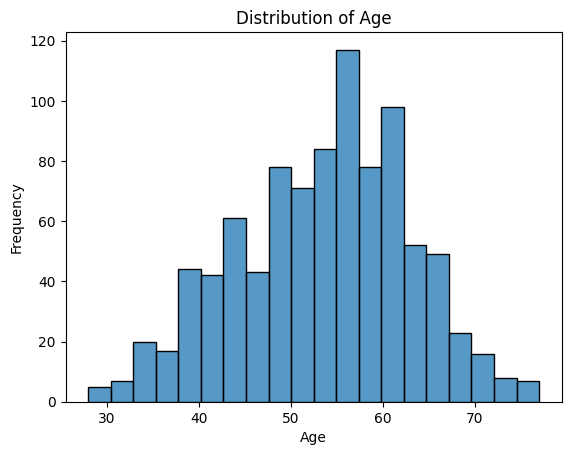

In [15]:
plt.figure()
sns.histplot(df["age"], bins=20)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

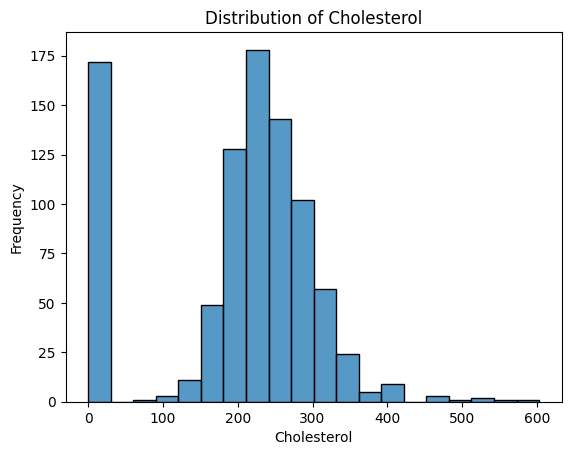

In [16]:
plt.figure()
sns.histplot(df["chol"], bins=20)
plt.title("Distribution of Cholesterol")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")
plt.show()

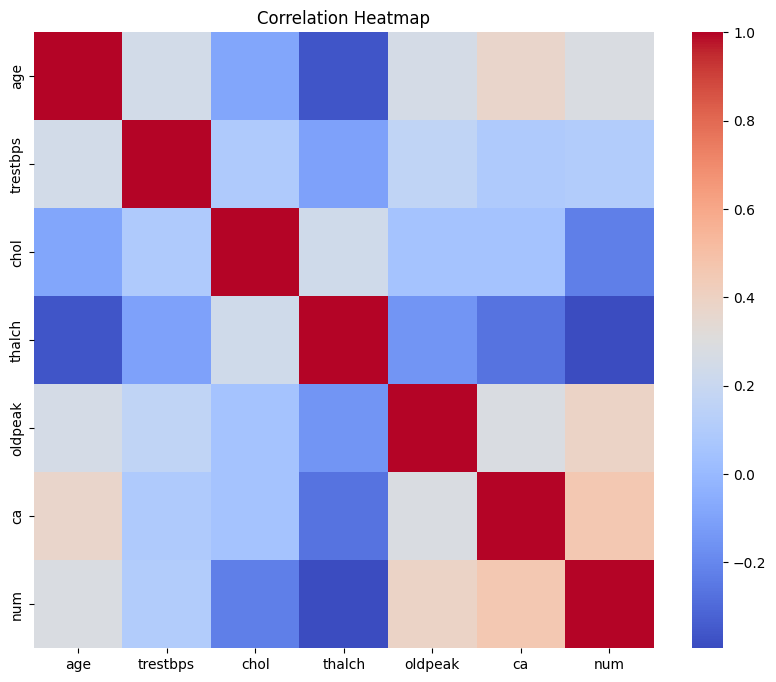

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

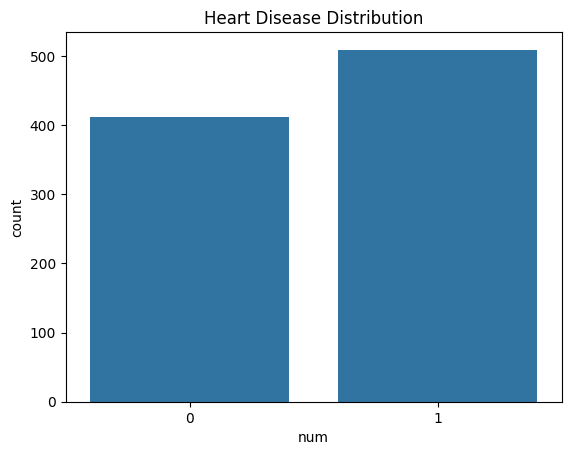

In [18]:
sns.countplot(x="num", data=df)
plt.title("Heart Disease Distribution")
plt.show()

In [19]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
# Train models
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(random_state=42)
knn = KNeighborsClassifier()

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [22]:
# Evaluate models
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

In [23]:
evaluate_model(lr, "Logistic Regression")
evaluate_model(rf, "Random Forest")
evaluate_model(knn, "KNN")


Logistic Regression
Accuracy: 0.842391304347826
Precision: 0.8411214953271028
Recall: 0.8823529411764706
F1 Score: 0.861244019138756

Random Forest
Accuracy: 0.8695652173913043
Precision: 0.8482142857142857
Recall: 0.9313725490196079
F1 Score: 0.8878504672897196

KNN
Accuracy: 0.8532608695652174
Precision: 0.8504672897196262
Recall: 0.8921568627450981
F1 Score: 0.8708133971291866


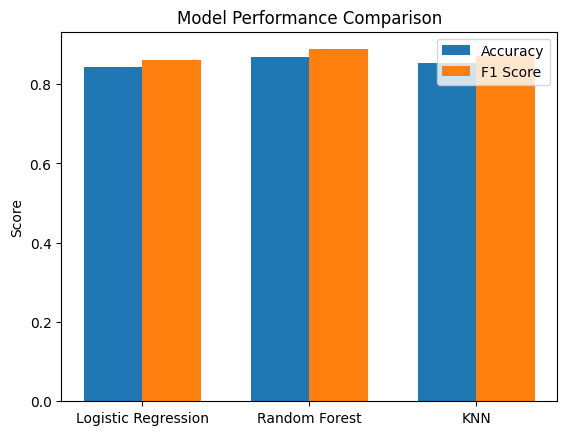

In [24]:
models = ["Logistic Regression", "Random Forest", "KNN"]

# Metrics from your results
accuracy = [0.8424, 0.8696, 0.8533]
f1_scores = [0.8612, 0.8879, 0.8708]

x = np.arange(len(models))
width = 0.35

plt.figure()
plt.bar(x - width/2, accuracy, width, label="Accuracy")
plt.bar(x + width/2, f1_scores, width, label="F1 Score")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()

plt.show()

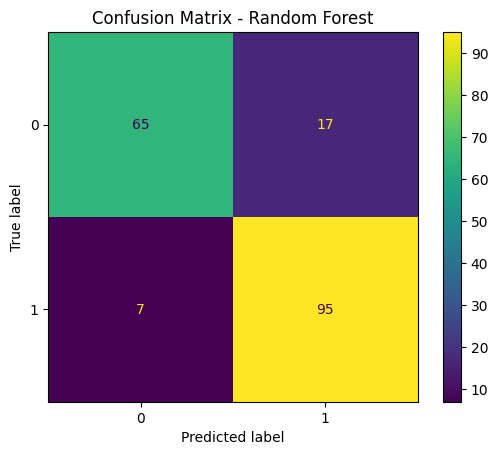

In [25]:
y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [26]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}

# Grid search
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

# Best model
rf = rf_grid.best_estimator_

print("Best Parameters:", rf_grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [27]:
evaluate_model(rf, "Tuned Random Forest")


Tuned Random Forest
Accuracy: 0.8532608695652174
Precision: 0.8440366972477065
Recall: 0.9019607843137255
F1 Score: 0.8720379146919431


In [28]:
# Get feature importance
feature_importance = rf.feature_importances_

# Get feature names (after encoding)
feature_names = X.columns

In [29]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

In [30]:
import pickle
import pandas as pd
import numpy as np

artifacts = {
    "model": rf,
    "scaler": scaler,
    "feature_columns": X.columns.tolist(),
    "numerical_cols": numerical_cols,
    "categorical_cols": categorical_cols,
    "num_imputer": num_imputer,
    "cat_imputer": cat_imputer,
    "importance_df": importance_df,
    "baseline_values": {
        col: (X[col].mode()[0] if col in categorical_cols else float(X[col].median()))
        for col in X.columns
    },
}

with open("artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)

In [31]:
# Sort by importance
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Show top 10 features
print(importance_df.head(10))

               Feature  Importance
2                 chol    0.137366
3               thalch    0.119468
0                  age    0.119157
4              oldpeak    0.108719
13          exang_True    0.108640
7   cp_atypical angina    0.087916
1             trestbps    0.074300
6             sex_Male    0.049100
8       cp_non-anginal    0.033685
16         thal_normal    0.029399


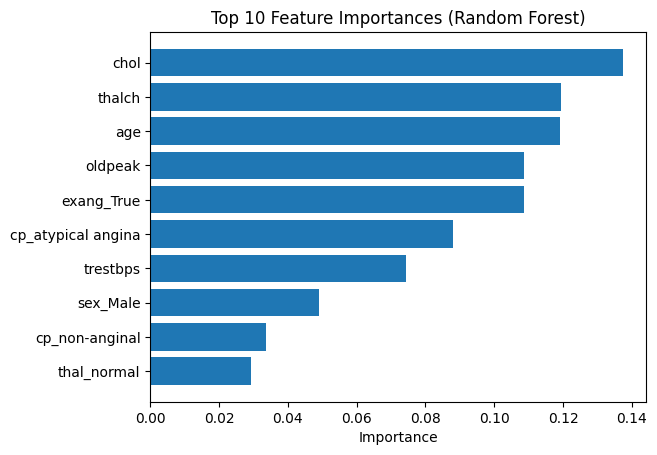

In [32]:
top_features = importance_df.head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()